In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib



In [2]:
# Charger les données (ville en index)
df = pd.read_csv('villes.csv', sep=';', index_col=0)

# 1. Préparation des données
labels = df.index.values
X = df.values

# 2. Standardisation des données (important avant PCA et KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Application de l'ACP (PCA) pour réduire à 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [3]:
# 4. Application de KMeans pour obtenir 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
clustering = kmeans.labels_
print(clustering)


C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[1 2 2 0 1 1 2 2 0 0 2 0 2 2 1 1 0 2 1 1 0 2 1 0 2 0 0 0 1 2 2 2]


Clustering terminé, graphique sauvegardé dans clusters_villes.png


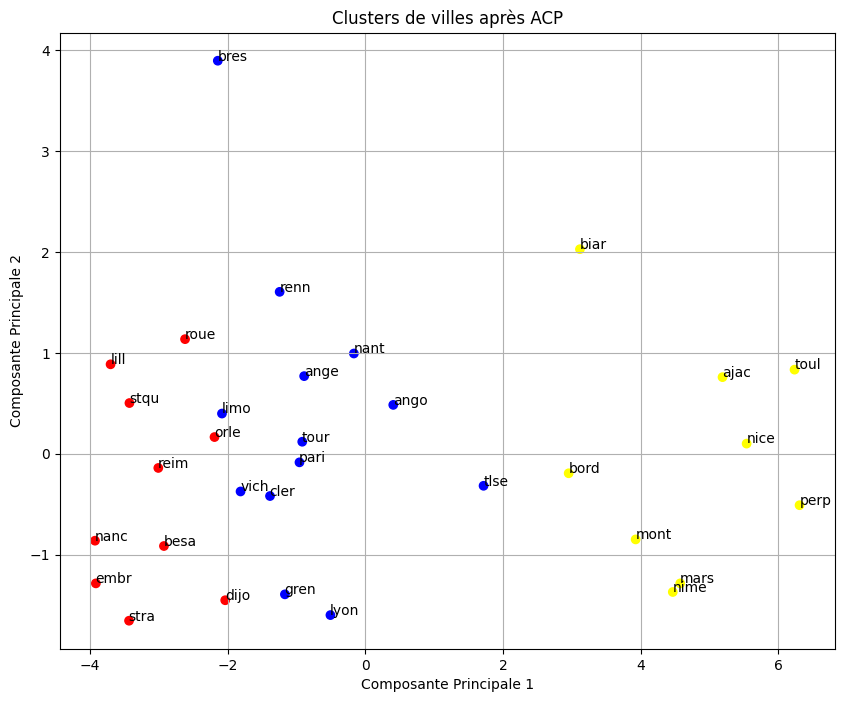

In [4]:
# 5. Visualisation (Code fourni mis à jour pour 3 couleurs de clusters)
colors = ['red', 'yellow', 'blue'] # 3 clusters = 3 couleurs
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clustering, 
            cmap=matplotlib.colors.ListedColormap(colors))

for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points')

plt.title('Clusters de villes après ACP')
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.grid(True)
plt.savefig('clusters_villes.png')
print("Clustering terminé, graphique sauvegardé dans clusters_villes.png")


Graphique sauvegardé dans agglomerative_clusters_villes.png


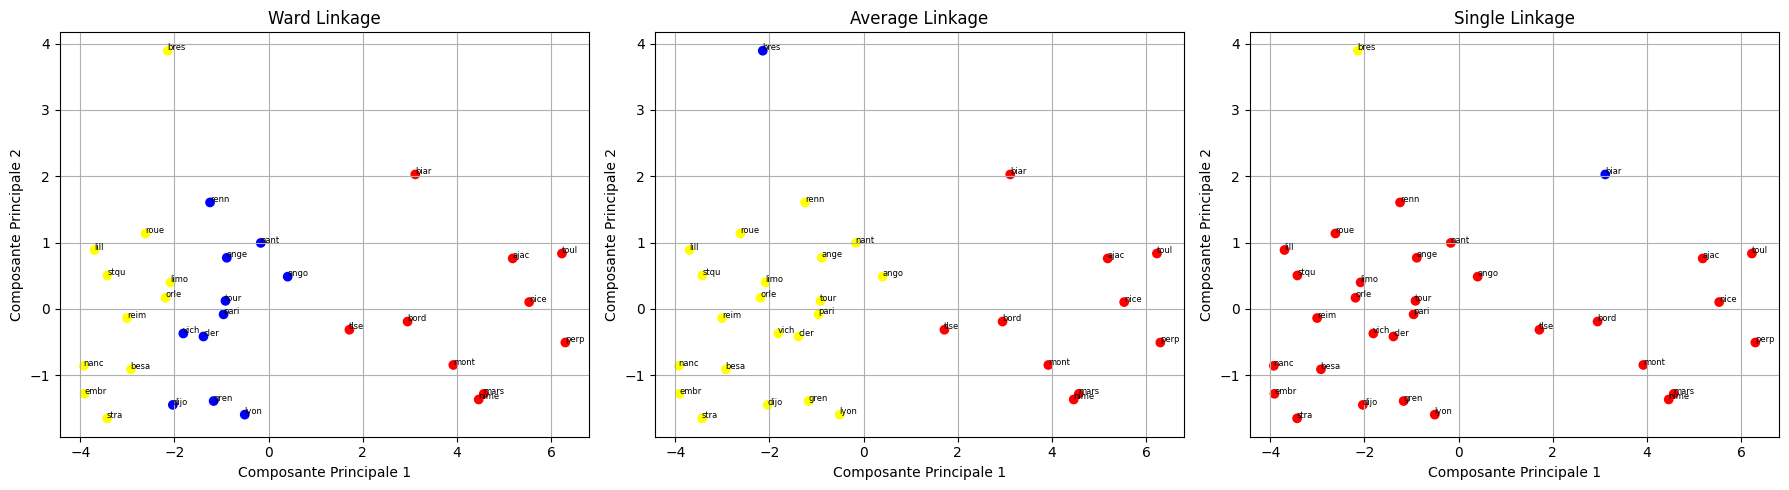

In [10]:
# 6. Agglomerative Clustering avec trois méthodes (ward, average, single)
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import matplotlib

linkages = ['ward', 'average', 'single']
colors = ['red', 'yellow', 'blue']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, linkage in enumerate(linkages):
    agg_cluster = AgglomerativeClustering(n_clusters=3, linkage=linkage)
    labels_agg = agg_cluster.fit_predict(X_scaled)
    
    ax = axes[idx]
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_agg, cmap=matplotlib.colors.ListedColormap(colors))
    
    for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
        ax.annotate(label, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points', fontsize=6)
        
    ax.set_title(f"{linkage.capitalize()} Linkage")
    ax.set_xlabel('Composante Principale 1')
    ax.set_ylabel('Composante Principale 2')
    ax.grid(True)

plt.tight_layout()
plt.savefig('agglomerative_clusters_villes.png')
print("Graphique sauvegardé dans agglomerative_clusters_villes.png")
plt.show()


Graphique sauvegardé dans silhouette_scores_kmeans.png


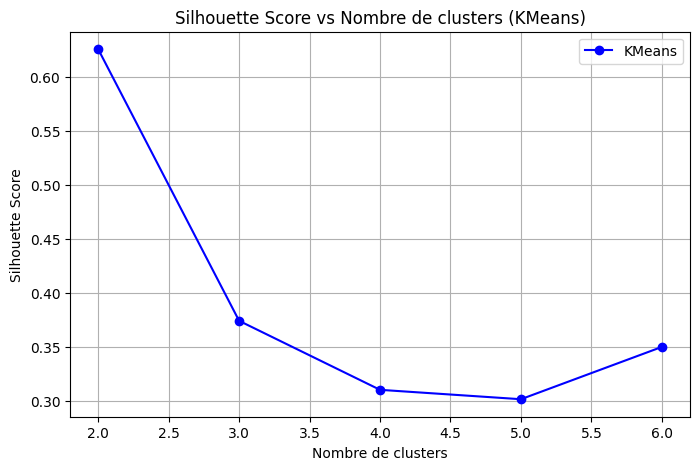

Meilleure partition pour KMeans: 2 clusters avec un score de 0.6256


In [11]:
# 7. Détermination de la meilleure partition avec le critère Silhouette
from sklearn.metrics import silhouette_score
import numpy as np

range_n_clusters = range(2, 7)
silhouette_kmeans = []

for n_clusters in range_n_clusters:
    # KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels_k = kmeans.fit_predict(X_scaled)
    silhouette_kmeans.append(silhouette_score(X_scaled, cluster_labels_k))

plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, silhouette_kmeans, marker='o', label='KMeans', color='blue')
plt.xlabel('Nombre de clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Nombre de clusters (KMeans)')
plt.legend()
plt.grid(True)
plt.savefig('silhouette_scores_kmeans.png')
print("Graphique sauvegardé dans silhouette_scores_kmeans.png")
plt.show()

best_k = range_n_clusters[np.argmax(silhouette_kmeans)]
print(f"Meilleure partition pour KMeans: {best_k} clusters avec un score de {max(silhouette_kmeans):.4f}")


Graphique sauvegardé dans silhouette_scores_agg.png


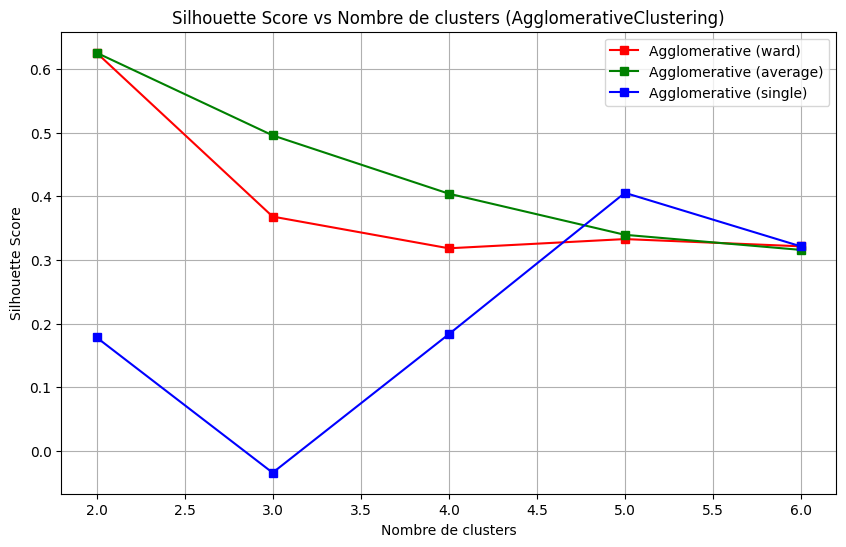

Meilleure partition pour AgglomerativeClustering (ward) : 2 clusters avec un score de 0.6256
Meilleure partition pour AgglomerativeClustering (average) : 2 clusters avec un score de 0.6256
Meilleure partition pour AgglomerativeClustering (single) : 5 clusters avec un score de 0.4054


In [12]:
# 8. Détermination de la meilleure partition (AgglomerativeClustering)
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

range_n_clusters = range(2, 7)
linkages = ['ward', 'average', 'single']
silhouette_agg = {linkage: [] for linkage in linkages}

for linkage in linkages:
    for n_clusters in range_n_clusters:
        agg = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
        cluster_labels_a = agg.fit_predict(X_scaled)
        silhouette_agg[linkage].append(silhouette_score(X_scaled, cluster_labels_a))

plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']
for idx, linkage in enumerate(linkages):
    plt.plot(range_n_clusters, silhouette_agg[linkage], marker='s', label=f'Agglomerative ({linkage})', color=colors[idx])

plt.xlabel('Nombre de clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Nombre de clusters (AgglomerativeClustering)')
plt.legend()
plt.grid(True)
plt.savefig('silhouette_scores_agg.png')
print("Graphique sauvegardé dans silhouette_scores_agg.png")
plt.show()

for linkage in linkages:
    scores = silhouette_agg[linkage]
    best_a = range_n_clusters[np.argmax(scores)]
    print(f"Meilleure partition pour AgglomerativeClustering ({linkage}) : {best_a} clusters avec un score de {max(scores):.4f}")


### Réponses aux questions d'analyse

**1. Meilleure partition globale pour AgglomerativeClustering:**
D'après l'indice de Silhouette maximal calculé précédemment, la meilleure partition est obtenue avec la méthode **Ward** pour **k = 2** clusters (Score Silhouette ≈ 0.6256).

**2. Pour k = 3 clusters, quelle méthode donne la meilleure partition ?**
En comparant toutes les méthodes (KMeans et Agglomerative) spécifiquement pour exactement 3 clusters, la méthode qui donne la meilleure partition est **AgglomerativeClustering avec le critère d'agrégation 'average'** (Score Silhouette ≈ 0.5).
